<a href="https://colab.research.google.com/github/AbubakarMA/Abu/blob/main/Linear_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

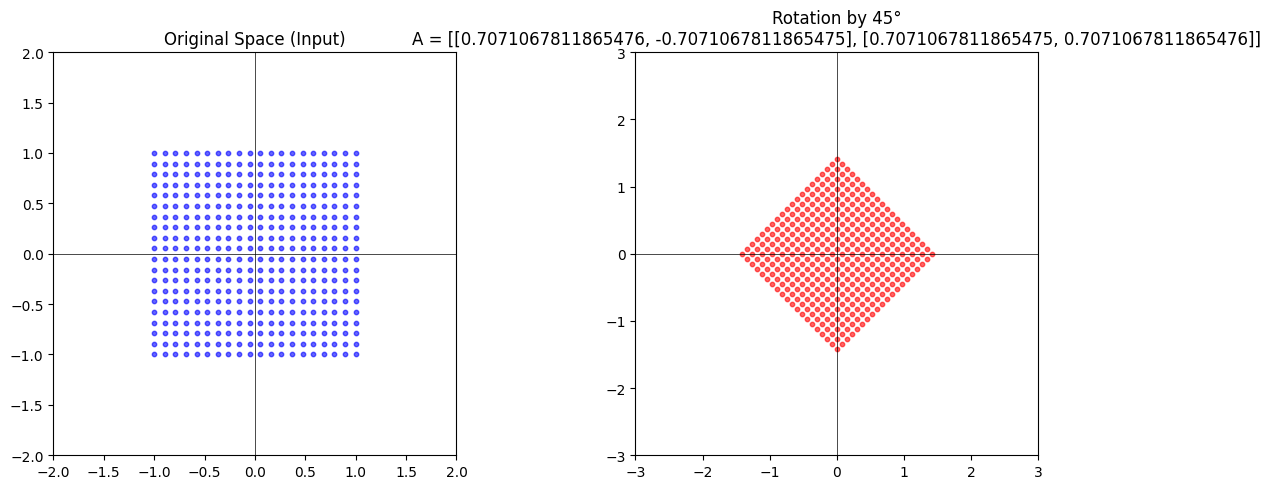

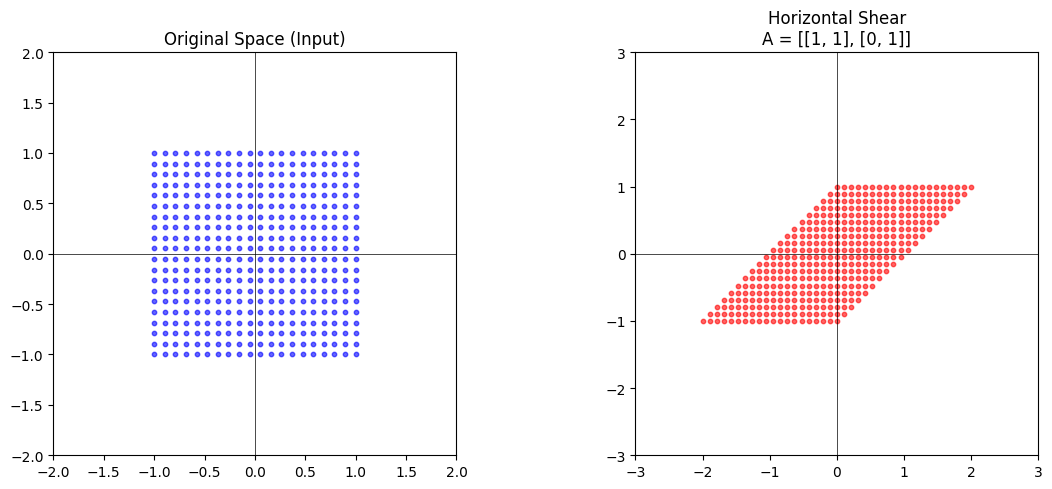

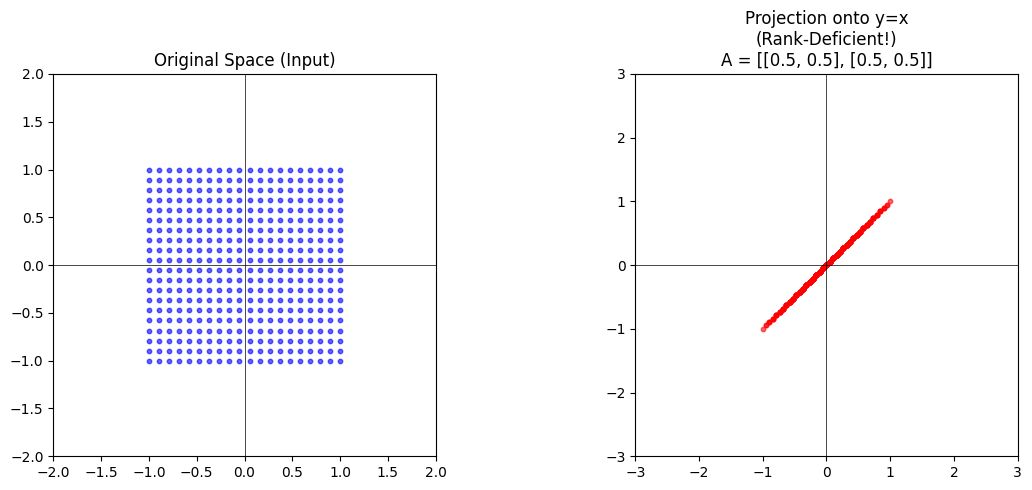

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_linear_map(A, title="Linear Transformation"):
    """Visualizes how matrix A transforms a unit square grid."""
    # Create a grid of points in R^2
    x = np.linspace(-1, 1, 20)
    y = np.linspace(-1, 1, 20)
    X, Y = np.meshgrid(x, y)
    points = np.stack([X.ravel(), Y.ravel()], axis=0)  # Shape: (2, 400)

    # Apply the linear map: y = Ax
    transformed = A @ points

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Original space
    ax1.scatter(points[0], points[1], c='blue', s=10, alpha=0.6)
    ax1.set_title("Original Space (Input)")
    ax1.set_xlim(-2, 2); ax1.set_ylim(-2, 2)
    ax1.axhline(0, color='k', linewidth=0.5); ax1.axvline(0, color='k', linewidth=0.5)
    ax1.set_aspect('equal')

    # Transformed space
    ax2.scatter(transformed[0], transformed[1], c='red', s=10, alpha=0.6)
    ax2.set_title(f"{title}\nA = {A.tolist()}")
    ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
    ax2.axhline(0, color='k', linewidth=0.5); ax2.axvline(0, color='k', linewidth=0.5)
    ax2.set_aspect('equal')

    plt.tight_layout()
    plt.show()

# Example 1: Rotation (preserves area, det=1)
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
plot_linear_map(R, "Rotation by 45°")

# Example 2: Shear (area preserved but shape distorted)
S = np.array([[1, 1],
              [0, 1]])
plot_linear_map(S, "Horizontal Shear")

# Example 3: Projection onto line y=x (collapses dimension, det=0)
P = np.array([[0.5, 0.5],
              [0.5, 0.5]])
plot_linear_map(P, "Projection onto y=x\n(Rank-Deficient!)")

Max difference: 1.78e-15
X^T · residual = [-1.33411077e-14  1.23512311e-14]


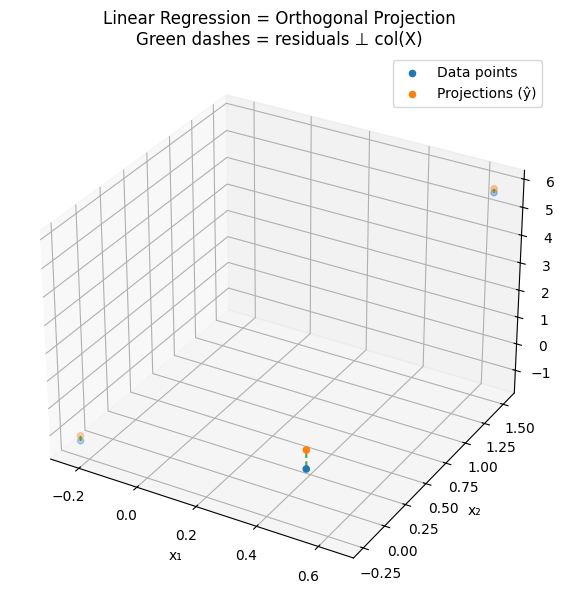

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic data: y = 2*x1 + 3*x2 + noise
np.random.seed(42)
N = 50
X = np.random.randn(N, 2)          # Design matrix (N x 2)
true_theta = np.array([2.0, 3.0])
noise = 0.5 * np.random.randn(N)
y = X @ true_theta + noise         # Target vector (N,)

# === Method 1: Solve via Normal Equations (Algebra) ===
theta_ml = np.linalg.solve(X.T @ X, X.T @ y)
y_hat_algebra = X @ theta_ml

# === Method 2: Project y onto col(X) (Geometry) ===
# Projection matrix P = X(X^T X)^{-1} X^T
P = X @ np.linalg.solve(X.T @ X, X.T)
y_hat_geometry = P @ y

# Verify they are identical
print(f"Max difference: {np.max(np.abs(y_hat_algebra - y_hat_geometry)):.2e}")
# Output: Max difference: ~1e-15 (machine precision!)

# === Verify Orthogonality ===
residual = y - y_hat_geometry
dot_products = X.T @ residual
print(f"X^T · residual = {dot_products}")
# Should be ≈ [0, 0] — residual is orthogonal to col(X)!

# === 3D Visualization (using first 2 samples for viz) ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Use first 3 data points for 3D visualization
idx = [0, 1, 2]
ax.scatter(X[idx,0], X[idx,1], y[idx], 'bo', label='Data points')
ax.scatter(X[idx,0], X[idx,1], y_hat_geometry[idx], 'r^', label='Projections (ŷ)')

# Draw residual lines (orthogonal to col(X))
for i in idx:
    ax.plot([X[i,0], X[i,0]], [X[i,1], X[i,1]],
            [y[i], y_hat_geometry[i]], 'g--', alpha=0.7)

ax.set_xlabel('x₁'); ax.set_ylabel('x₂'); ax.set_zlabel('y')
ax.set_title("Linear Regression = Orthogonal Projection\nGreen dashes = residuals ⊥ col(X)")
ax.legend()
plt.show()

In [ ]:
class Tensor:
    """Minimal autograd tensor implementing reverse-mode autodiff."""
    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None  # Will be set during ops
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Tensor({self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad      # ∂out/∂self = 1
            other.grad += out.grad     # ∂out/∂other = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad   # ∂out/∂self = other
            other.grad += self.data * out.grad   # ∂out/∂other = self
        out._backward = _backward
        return out

    def relu(self):
        out = Tensor(max(0, self.data), (self,), 'relu')

        def _backward():
            self.grad += (out.data > 0) * out.grad  # ∂relu/∂x = 1 if x>0 else 0
        out._backward = _backward
        return out

    def backward(self):
        """Topological sort + reverse-mode gradient propagation."""
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0  # dL/dL = 1
        for node in reversed(topo):  # ← THIS IS BACKPROPAGATION
            node._backward()

# === Demo: Manual Neural Network Forward + Backward ===
# Simulate: L = relu(w1*x + b1) * w2
x  = Tensor(2.0)
w1 = Tensor(0.5)
b1 = Tensor(-1.0)
w2 = Tensor(3.0)

# Forward pass (builds computation graph automatically)
h = (w1 * x + b1).relu()   # Hidden layer
L = h * w2                  # Loss/output

print(f"Forward: L = {L}")   # relu(0.5*2 - 1) * 3 = relu(0)*3 = 0

# Backward pass (automatic gradient computation)
L.backward()

print(f"\nGradients computed via reverse-mode autodiff:")
print(f"  dL/dw1 = {w1.grad:.4f}")  # Should be 0 (ReLU killed gradient)
print(f"  dL/db1 = {b1.grad:.4f}")  # Should be 0
print(f"  dL/dw2 = {w2.grad:.4f}")  # Should be 0 (h=0)

# Now change b1 so ReLU activates
b1 = Tensor(0.5)  # w1*x + b1 = 0.5*2 + 0.5 = 1.5 > 0
h = (w1 * x + b1).relu()
L = h * w2
L.backward()

print(f"\nWith b1=0.5 (ReLU active):")
print(f"  dL/dw1 = {w1.grad:.4f}")  # = w2 * x = 3*2 = 6
print(f"  dL/db1 = {b1.grad:.4f}")  # = w2 * 1 = 3
print(f"  dL/dw2 = {w2.grad:.4f}")  # = h = 1.5

Forward: L = Tensor(0.0000, grad=0.0000)

Gradients computed via reverse-mode autodiff:
  dL/dw1 = 0.0000
  dL/db1 = 0.0000
  dL/dw2 = 0.0000

With b1=0.5 (ReLU active):
  dL/dw1 = 6.0000
  dL/db1 = 3.0000
  dL/dw2 = 1.5000
